# 鹤岗市区应届生的点是怎么来的？

鹤岗和大庆、绥化**考的是同一份试卷**，但是我们没有鹤岗的中考成绩单，只知道高考前面的人。
所以和哈尔滨一样，只能比**位置**。区别在于：鹤岗没有中考分数分布，必须**假设**一个。

做法：

1. 鹤岗市区约有 **6400** 名中考考生（依据：鹤岗市教育局 2006-07-05《我市 2006 年中考工作圆满完成》：「市区报考普通高中考生有 6471 人」，取整并视为各年大致稳定，[https://web.archive.org/web/20060717204657/http://www.hgedu.gov.cn:80/gengduo/xinxi/200607052.htm](https://web.archive.org/web/20060717204657/http://www.hgedu.gov.cn:80/gengduo/xinxi/200607052.htm)），**分数分布假设和绥化市区一样**（629 分以下 N(533.5, 36.3²)，629 分及以上 N(579, 19²)，两段在 629 处衔接；见《绥化》那两个 notebook）；
2. 第 N 个位置的中考分，取这个分布的「前 (N − 0.5) ÷ 6400」分位；
3. 用大庆红线，由这个中考分得到「预测高考分」；
4. 鹤岗一中、三中理科应届生的高考分从高到低排序，**第 N 高**就是「实际」。实际 − 预测就是鹤岗相对大庆曲线的高低。

## 0 读数据

In [1]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def find(name):   # 在 content/kao 里运行，或从仓库根目录运行均可
    return next(p for p in [Path(name), Path('content/kao')/name] if p.exists())
rd = lambda name: pd.read_csv(find(name), encoding='utf-8-sig')

# ---- 红线：大庆市区应届 Q-Q 曲线（做法见《大庆市区应届 Q-Q 曲线的来源》）----
roster = rd('2004年大庆中考录取总表.csv')
roster['文体'] = pd.to_numeric(roster['文化课+体育成绩'])
city_rank = lambda z: int((roster['文体'] > z).sum() + 1)          # 中考分 → 大庆市区位次
ys = rd('2007年高考理科一分一段表.csv').sort_values('累计人数')
score_of_m = lambda m: float(np.interp(m, ys['累计人数'], ys['分数']))   # 全省位次 → 高考分
ANCH = [(2, 16.4), (12, 84), (30, 225), (56, 339), (87, 510), (129, 693), (177, 942), (234, 1227), (274, 1598)]

def m_of_n(n):
    # 市区应届位次 n → 全省位次 m：锚点间 log-log 线性；n < 2 时沿第一段延长；n > 274 返回 None
    if n > ANCH[-1][0]: return None
    i = 0
    while i < len(ANCH) - 2 and n > ANCH[i + 1][0]: i += 1
    (n0, m0), (n1, m1) = ANCH[i], ANCH[i + 1]
    w = (math.log(n) - math.log(n0)) / (math.log(n1) - math.log(n0))
    return math.exp(math.log(m0) + w * (math.log(m1) - math.log(m0)))

g_of_n = lambda n: None if m_of_n(n) is None else score_of_m(m_of_n(n))      # 位次 → 预测高考分

# 红线按中考分查表（623–660 逐分），之后对任意小数分线性插值
tab = pd.DataFrame({'z': range(623, 664)})
tab['g'] = [g_of_n(city_rank(z)) for z in tab['z']]
red = lambda z: float(np.interp(z, tab['z'], tab['g'])) if 623 <= z <= 663 else np.nan

hg_all = rd('2004年中考和2007年高考鹤岗市.csv')
print('名单：', len(hg_all), '人；', hg_all['毕业高中'].value_counts().to_dict())
hg_df = hg_all[hg_all['毕业高中'].isin(['鹤岗市第一中学', '鹤岗市第三中学']) & (hg_all['科类'] == '理科')]
g_hg = np.sort(hg_df['2007高考成绩'].to_numpy())[::-1]
print(f'鹤岗一中、三中理科应届 {len(hg_df)} 人（不含绥滨、萝北、绥棱县校），最低 {g_hg.min():.0f} 分，最高 {g_hg.max():.0f} 分')

名单： 89 人； {'鹤岗市第一中学': 67, '鹤岗市第三中学': 17, '绥缤县一中': 3, '绥滨县职业高中': 1, '萝北县高级中学': 1}
鹤岗一中、三中理科应届 84 人（不含绥滨、萝北、绥棱县校），最低 632 分，最高 703 分


**要注意：名单只到高考 632 分为止。** 它是「鹤岗应届前若干名」，不是全体——所以只有靠前的位置是完整的，我们取到第 84 个位置为止。

**不含**绥滨、萝北、绥棱县的学校：他们不在鹤岗**市区**中考的名额里，和我们假设的「市区 6400 人」不是同一个总体。
名单里的人**已经剔除了复读生**（生源性质：应届）。

## 1 假设一个中考分布，求每个位置的中考分

绥化市区的分布来自两个节点（571 分/742 人、600 分/165 人）加上 629 分以上换成 σ=19 的假设。这里直接把它搬到鹤岗，只把总人数换成 6400：

- 前 (N − 0.5) ÷ 6400 比例 ≤ 0.43%（即前约 27 个位置）→ 用 629 分以上那段 N(579, 19²)；
- 否则 → 用 N(533.5, 36.3²)。

0.43% 是 629 分在绥化分布里的占比（≈21/4923），接缝处两段占比相同，所以位置到分数是连续的。

In [2]:
MU_A, SIG_A, MU_B, SIG_B, X0 = 533.5, 36.3, 579, 19, 629
Q0 = norm.sf((X0 - MU_A) / SIG_A)                     # 629 分在绥化分布里的占比 ≈ 0.43%

def z_of_position(Nn, total=6400, two_seg=True):
    q = (Nn - 0.5) / total
    if two_seg and q < Q0:
        return MU_B + SIG_B * norm.isf(q)
    return MU_A + SIG_A * norm.isf(q)

Nn = np.arange(1, len(g_hg) + 1)
z_hg = np.array([z_of_position(n) for n in Nn])
print(f'629 分的占比 {Q0:.4%}，在 6400 人里约前 {Q0 * 6400:.0f} 个位置')
pd.DataFrame({'位置 N': [1, 2, 3, 5, 10, 20, 27, 28, 40, 60, 84], '中考分': [round(z_hg[n-1], 1) for n in [1, 2, 3, 5, 10, 20, 27, 28, 40, 60, 84]]}).set_index('位置 N').T

629 分的占比 0.4259%，在 6400 人里约前 27 个位置


位置 N,1,2,3,5,10,20,27,28,40,60,84
中考分,650.8,645.5,642.8,639.7,635.4,631.1,629.2,628.9,624.3,618.9,614.3


## 2 红线预测与比较

由「定位中考分」查红线得到预测高考分（红线在中考 623–660 分之间有定义；位置太靠后、中考分低于 623 的，超出红线范围，不计差值）。
第 1 位解斌（703 分）高于曲线 11 分，是孤立值，**像哈尔滨排除 718 一样排除**。

In [3]:
pred_hg = np.array([red(z) if z >= 623 else np.nan for z in z_hg])
diff_hg = g_hg - pred_hg
ok = (Nn >= 2) & ~np.isnan(diff_hg)                      # 排除第 1 位，且在红线范围内
print(f'第 1 位：实际 {g_hg[0]:.0f}，预测 {pred_hg[0]:.1f}，高 {diff_hg[0]:+.1f}（排除）')
print(f'纳入统计的位置：{ok.sum()} 个（中考 ≥623），平均差 {np.nanmean(diff_hg[ok]):+.2f}，中位数 {np.nanmedian(diff_hg[ok]):+.2f}')
print('前 10 名：实际 − 预测 =', np.round(diff_hg[1:10], 1).tolist())
pd.DataFrame({'N': Nn[:10], '定位中考': z_hg[:10].round(1), '预测高考': pred_hg[:10].round(1), '实际': g_hg[:10], '差': diff_hg[:10].round(1)}).set_index('N').T

第 1 位：实际 703，预测 692.2，高 +10.8（排除）
纳入统计的位置：34 个（中考 ≥623），平均差 -0.39，中位数 -1.03
前 10 名：实际 − 预测 = [-0.5, 3.5, -1.0, -1.5, -1.8, -0.7, 1.2, 1.0, 1.1]


N,1,2,3,4,5,6,7,8,9,10
定位中考,650.8,645.5,642.8,641.0,639.7,638.6,637.6,636.8,636.1,635.4
预测高考,692.2,686.5,679.5,677.0,675.5,673.8,671.7,669.8,669.0,667.9
实际,703.0,686.0,683.0,676.0,674.0,672.0,671.0,671.0,670.0,669.0
差,10.8,-0.5,3.5,-1.0,-1.5,-1.8,-0.7,1.2,1.0,1.1


## 3 为什么不能只用一条正态？

如果鹤岗的中考分布也只用单一的 N(533.5, 36.3²)（不压缩 629 分以上），顶端的位置会被**高估很多**：

In [4]:
z_single = np.array([z_of_position(n, two_seg=False) for n in Nn])
pred_single = np.array([red(z) for z in z_single])           # 超出红线范围（>663）的位置给 nan
diff_single = g_hg - pred_single
print('第 1 位定位中考：两段', round(z_hg[0], 1), '；单段', round(z_single[0], 1))
print('前 5 位定位中考：两段', z_hg[:5].round(1).tolist())
print('              单段', z_single[:5].round(1).tolist())
k = (Nn >= 2) & ~np.isnan(diff_single) & ~np.isnan(diff_hg)
print(f'两种分布都能比较的位置 {k.sum()} 个：平均差 两段 {diff_hg[k].mean():+.1f}，单段 {diff_single[k].mean():+.1f}')
print(f'单段下定位中考 > 663（比大庆最高分还高，红线查不到）的位置数：{int((z_single > 663).sum())}')

第 1 位定位中考：两段 650.8 ；单段 670.7
前 5 位定位中考：两段 [650.8, 645.5, 642.8, 641.0, 639.7]
              单段 [670.7, 660.5, 655.4, 652.0, 649.4]
两种分布都能比较的位置 34 个：平均差 两段 -0.4，单段 -6.2
单段下定位中考 > 663（比大庆最高分还高，红线查不到）的位置数：1


## 4 出图

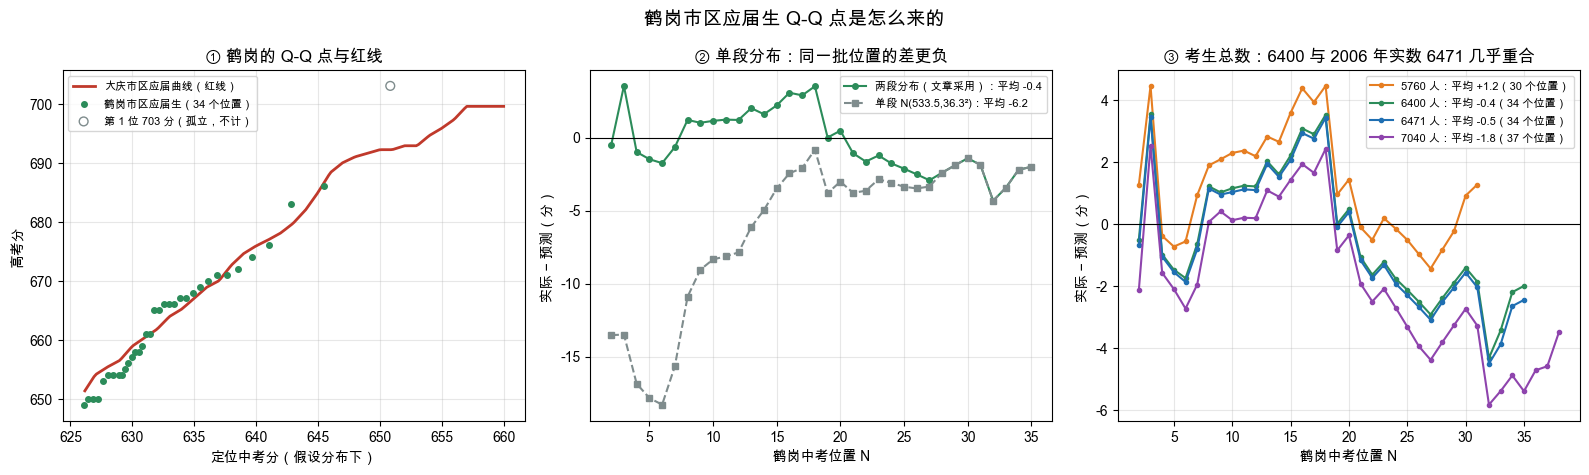

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
BLUE, RED, GREY, MOSS = '#1f6fb2', '#c0392b', '#7f8c8d', '#2c8c5a'

a = ax[0]
zr = np.linspace(623, 660, 200); a.plot(zr, [red(z) for z in zr], color=RED, lw=2, label='大庆市区应届曲线（红线）')
a.scatter(z_hg[ok], g_hg[ok], s=16, color=MOSS, zorder=3, label=f'鹤岗市区应届生（{ok.sum()} 个位置）')
a.scatter(z_hg[:1], g_hg[:1], s=40, facecolor='none', edgecolor=GREY, label='第 1 位 703 分（孤立，不计）')
a.set_xlabel('定位中考分（假设分布下）'); a.set_ylabel('高考分'); a.set_title('① 鹤岗的 Q-Q 点与红线'); a.legend(fontsize=8); a.grid(alpha=.3)

a = ax[1]
k = (Nn >= 2) & ~np.isnan(diff_hg) & ~np.isnan(diff_single)
a.plot(Nn[k], diff_hg[k], 'o-', ms=4, color=MOSS, label=f'两段分布（文章采用）：平均 {diff_hg[k].mean():+.1f}')
a.plot(Nn[k], diff_single[k], 's--', ms=4, color=GREY, label=f'单段 N(533.5,36.3²)：平均 {diff_single[k].mean():+.1f}')
a.axhline(0, color='k', lw=.8); a.set_xlabel('鹤岗中考位置 N'); a.set_ylabel('实际 − 预测（分）')
a.set_title('② 单段分布：同一批位置的差更负'); a.legend(fontsize=8); a.grid(alpha=.3)

# ③ 敏感度：市区考生数
a = ax[2]
for tot, col in [(5760, '#e67e22'), (6400, MOSS), (6471, BLUE), (7040, '#8e44ad')]:
    z_ = np.array([z_of_position(n, total=tot) for n in Nn]); p_ = np.array([red(z) if z >= 623 else np.nan for z in z_])
    d_ = g_hg - p_; kk = (Nn >= 2) & ~np.isnan(d_)
    a.plot(Nn[kk], d_[kk], 'o-', ms=3, color=col, label=f'{tot} 人：平均 {np.nanmean(d_[kk]):+.1f}（{kk.sum()} 个位置）')
a.axhline(0, color='k', lw=.8); a.set_xlabel('鹤岗中考位置 N'); a.set_ylabel('实际 − 预测（分）')
a.set_title('③ 考生总数：6400 与 2006 年实数 6471 几乎重合'); a.legend(fontsize=8); a.grid(alpha=.3)
fig.suptitle('鹤岗市区应届生 Q-Q 点是怎么来的', fontsize=14)
fig.tight_layout(); fig.savefig('2004年鹤岗市区应届Q-Q曲线的来源.png', dpi=150); plt.show()

## 5 6400 从哪来？敏感吗？

6400 的依据是鹤岗市教育局 2006-07-05 的报道《我市 2006 年中考工作圆满完成》：「市区报考普通高中考生有 **6471** 人，共有 221 个考场」。
这是 **2006 年**的数，用来代表 **2004 年**的市区考生，前提是各年人数大致稳定。上图③把总数换成几个值，看平均差怎么变：

In [6]:
def mean_diff(total):
    z_ = np.array([z_of_position(n, total=total) for n in Nn]); p_ = np.array([red(z) if z >= 623 else np.nan for z in z_])
    d_ = g_hg - p_; kk = (Nn >= 2) & ~np.isnan(d_)
    return d_[kk].mean(), int(kk.sum())
pd.DataFrame([{'市区考生数': tot, '说明': s_, '平均差': round(mean_diff(tot)[0], 2), '可比位置数': mean_diff(tot)[1]}
              for tot, s_ in [(5760, '6400 少 10%'), (6400, '文章采用'), (6471, '2006 年实数'), (7040, '6400 多 10%')]]).set_index('市区考生数')

,说明,平均差,可比位置数
市区考生数,,,
5760,6400 少 10%,1.25,30
6400,文章采用,-0.39,34
6471,2006 年实数,-0.54,34
7040,6400 多 10%,-1.82,37


**结论：** 6400 与 2006 年实数 6471 相差只有 71 人，平均差从 −0.39 变成 −0.54，只动 0.15 分（图③里两条线几乎重合）。
真正需要留意的只是「2006 年的数能否代表 2004 年」：如果两年相差 10%（约 ±650 人），平均差会变到 +1.3 或 −1.8，也就是动 1.3–1.8 分；仍然只有一两分，前几名依然落在红线附近。

另外，**没有扣除去外地读高中的尖子**：如果鹤岗前 15 个位置里有 2–4 人去了外地（例如哈尔滨、大庆），名单里就缺了他们，
实际的第 N 高会被低估，鹤岗整体会比这里算的再高 1–5 分。

## 6 结论与边界

1. **做法**：假设鹤岗市区 6400 人、分数分布同绥化（两段正态），第 N 个位置取分位 (N − 0.5) ÷ 6400 定位，再查大庆红线，与鹤岗一中、三中理科应届生高考第 N 高相比。
2. **能说**：分段分布让前十名基本落在红线上；单段分布把顶端的中考分定得过高（第 1 位 ≈671 分，比大庆最高分 663 还高），人为压低「实际 − 预测」。
3. **不能说**：
   - 鹤岗中考分布完全是假设（借绥化），没有鹤岗自己的中考数据；
   - 6400 取自 2006 年的市区报考人数（6471），拿它代表 2004 年；换成 ±10%，平均差在 +1.3 到 −1.8 之间；
   - 名单只到 632 分、不含县校和复读生，也没扣外流；
   - 第 1 位解斌（703）作为孤立值排除。